# Codebook Collapse — Visual Experiments

> **Goal:** Watch a codebook collapse, measure it with perplexity, and bring the dead codes back to life.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Collapse in action** | With a bad init, how many of K codes actually get used? |
| 2 | **Perplexity detector** | Can perplexity flag collapse before reconstruction visibly degrades? |
| 3 | **Random restart** | Does resetting dead codes to live encoder outputs restore utilization? |
| 4 | **Dimensionality** | Why does a higher code dimension D make collapse worse? |

---
**Linked theory:** [research/04-codebook-collapse.md](../research/04-codebook-collapse.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})


def assign(batch, codebook):
    d2 = ((batch[:, None, :] - codebook[None, :, :]) ** 2).sum(-1)
    return d2.argmin(1)


def perplexity(counts):
    """Effective number of codes used = exp(entropy of usage distribution)."""
    p = counts / max(counts.sum(), 1)
    p = p[p > 0]
    return float(np.exp(-(p * np.log(p)).sum()))


def make_blobs(n_per=400, seed=0):
    rng = np.random.default_rng(seed)
    centres = 4.0 * np.array([[np.cos(a), np.sin(a)] for a in np.linspace(0, 2 * np.pi, 8, endpoint=False)])
    return np.concatenate([c + 0.4 * rng.standard_normal((n_per, 2)) for c in centres])


print('Setup complete.')

Setup complete.


---
## Experiment 1: Collapse in action

**Question:** If the codebook is initialised badly — all codes crammed near the origin while data lives in eight far-flung blobs — how many of the K codes ever get selected?

We run EMA k-means updates. Because dead codes receive no updates, whichever codes start nearest to data win all the assignments, and the rest stay stuck — the vicious cycle of collapse.

In [2]:
rng = np.random.default_rng(1)
data = make_blobs(seed=1)
K = 64


def train_vq(data, codebook, steps=300, gamma=0.99, bs=256,
             restart=False, threshold=1.0, window=10, seed=0):
    rng = np.random.default_rng(seed)
    K, D = codebook.shape
    codebook = codebook.copy()
    N = np.ones(K)
    M = codebook.copy()
    ppl_hist, recent = [], np.zeros(K)
    for step in range(steps):
        batch = data[rng.integers(0, len(data), bs)]
        a = assign(batch, codebook)
        counts = np.bincount(a, minlength=K)
        ppl_hist.append(perplexity(counts))
        # EMA update
        sums = np.zeros((K, D))
        np.add.at(sums, a, batch)
        N = gamma * N + (1 - gamma) * counts
        M = gamma * M + (1 - gamma) * sums
        eps = 1e-5
        N_s = (N + eps) / (N.sum() + K * eps) * N.sum()
        codebook = M / N_s[:, None]
        # random restart of dead codes
        recent += counts
        if restart and (step + 1) % window == 0:
            dead = np.where(recent < threshold)[0]
            if len(dead):
                picks = batch[rng.integers(0, len(batch), len(dead))]
                codebook[dead] = picks
                M[dead] = picks
                N[dead] = 1.0
            recent[:] = 0
    final_counts = np.bincount(assign(data, codebook), minlength=K)
    return codebook, np.array(ppl_hist), final_counts


bad_init = 0.2 * rng.standard_normal((K, 2))   # all codes near origin
cb_bad, ppl_bad, counts_bad = train_vq(data, bad_init, restart=False, seed=2)
print(f'codes used: {(counts_bad > 0).sum()}/{K}   |   final perplexity: {perplexity(counts_bad):.1f}')

codes used: 6/64   |   final perplexity: 5.7


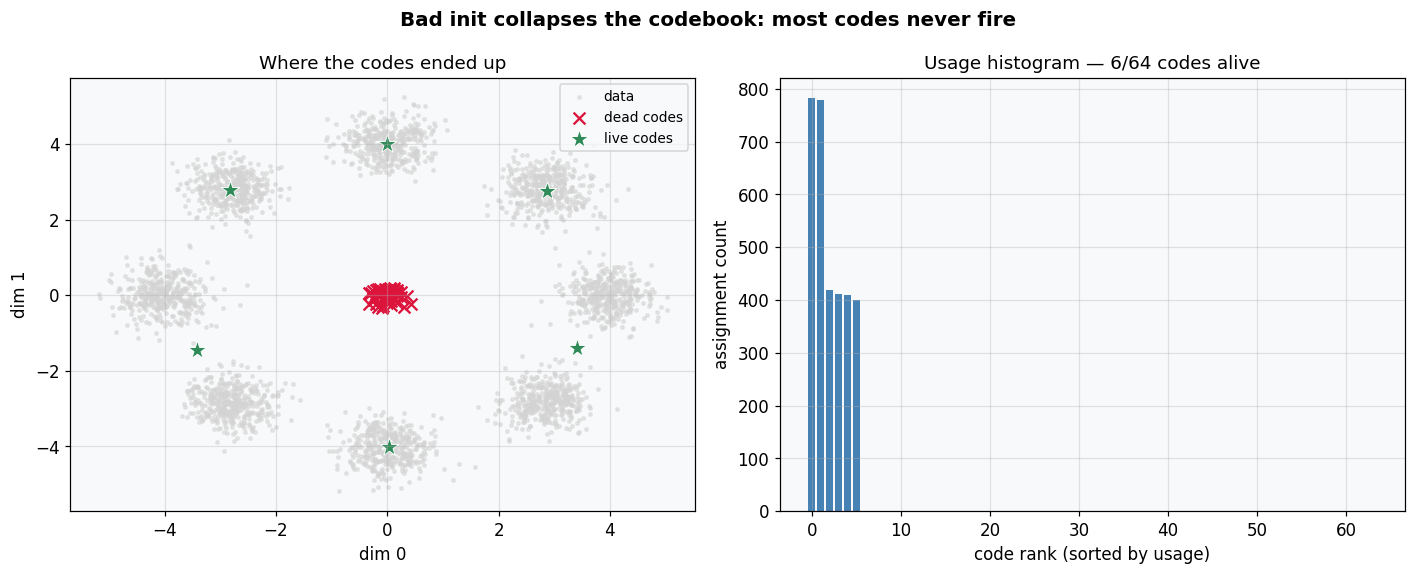

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
fig.suptitle('Bad init collapses the codebook: most codes never fire', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], s=5, color='lightgray', alpha=0.5, label='data')
alive = counts_bad > 0
ax.scatter(cb_bad[~alive, 0], cb_bad[~alive, 1], c='crimson', marker='x', s=60, label='dead codes')
ax.scatter(cb_bad[alive, 0], cb_bad[alive, 1], c='seagreen', marker='*', s=160,
           edgecolor='white', linewidth=0.6, label='live codes')
ax.set_xlabel('dim 0'); ax.set_ylabel('dim 1')
ax.set_title('Where the codes ended up')
ax.legend(loc='upper right', fontsize=9)

ax2 = axes[1]
ax2.bar(range(K), np.sort(counts_bad)[::-1], color='steelblue')
ax2.set_xlabel('code rank (sorted by usage)'); ax2.set_ylabel('assignment count')
ax2.set_title(f'Usage histogram — {(alive).sum()}/{K} codes alive')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows that only a handful of green live codes reached the data blobs, while a crowd of red dead codes stayed marooned near the origin. The right histogram is starkly skewed: a few codes absorb nearly all assignments and the long tail is flat zero.
2. **Why it looks this way:** A code only moves when it wins an `argmin`. Codes that start far from data never win, never update, and so never escape — the self-reinforcing collapse loop. The few codes that happened to be closest swallow all the data.
3. **Key takeaway:** A codebook of size K=64 can collapse to an effective vocabulary of a handful — the declared capacity is a lie unless you measure actual usage.

---
## Experiment 2: Perplexity detector

**Question:** Perplexity = exp(entropy of usage) reports the *effective* number of codes in use. Does it cleanly separate a collapsed run from a healthy one?

We compare the bad-init run against a healthy run initialised from random data points (a k-means-style init that places every code inside the data).

In [4]:
good_init = data[rng.integers(0, len(data), K)]   # init codes ON data points
cb_good, ppl_good, counts_good = train_vq(data, good_init, restart=False, seed=3)
print(f'healthy: {(counts_good > 0).sum()}/{K} codes used, perplexity {perplexity(counts_good):.1f}')
print(f'collapsed: {(counts_bad > 0).sum()}/{K} codes used, perplexity {perplexity(counts_bad):.1f}')

healthy: 64/64 codes used, perplexity 57.2
collapsed: 6/64 codes used, perplexity 5.7


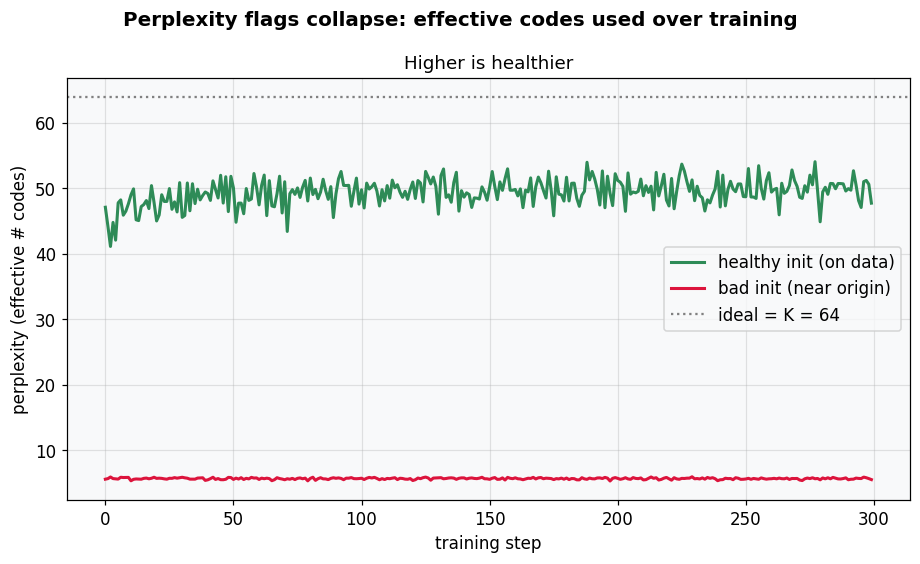

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.suptitle('Perplexity flags collapse: effective codes used over training', fontsize=13, fontweight='bold')

ax.plot(ppl_good, color='seagreen', lw=2, label='healthy init (on data)')
ax.plot(ppl_bad, color='crimson', lw=2, label='bad init (near origin)')
ax.axhline(K, color='gray', ls=':', label=f'ideal = K = {K}')
ax.set_xlabel('training step'); ax.set_ylabel('perplexity (effective # codes)')
ax.set_title('Higher is healthier')
ax.legend(loc='center right')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The healthy run's perplexity climbs and settles high (many codes sharing the load), while the bad-init run flatlines low — only a few effective codes throughout. The gap is obvious from the very first steps.
2. **Why it looks this way:** Perplexity is the exponential of usage entropy, so it equals K when usage is uniform and drops toward 1 when one code dominates. Collapse concentrates usage, which entropy — and therefore perplexity — captures directly.
3. **Key takeaway:** Perplexity is the single number to watch during VQ training; it signals collapse early, well before the reconstruction loss makes the problem obvious.

---
## Experiment 3: Random restart

**Question:** The most practical fix is to reset codes that have gone unused over a recent window to fresh encoder outputs. Does it actually restore utilization?

We rerun the *same bad init*, but every few steps any code with usage below a threshold is teleported to a random data point from the current batch — instantly putting it back where it can win assignments.

In [6]:
cb_fix, ppl_fix, counts_fix = train_vq(data, bad_init, restart=True,
                                       threshold=1.0, window=10, seed=2)
print(f'with restart: {(counts_fix > 0).sum()}/{K} codes used, perplexity {perplexity(counts_fix):.1f}')
print(f'without:      {(counts_bad > 0).sum()}/{K} codes used, perplexity {perplexity(counts_bad):.1f}')

with restart: 64/64 codes used, perplexity 50.2
without:      6/64 codes used, perplexity 5.7


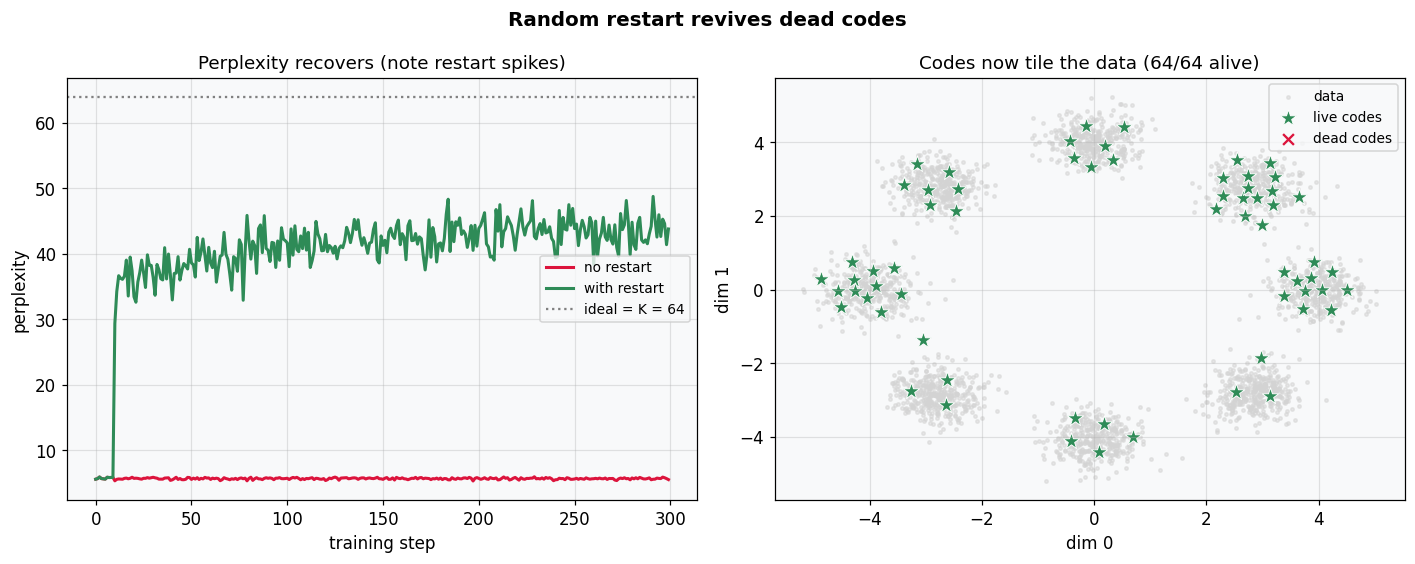

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.suptitle('Random restart revives dead codes', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(ppl_bad, color='crimson', lw=2, label='no restart')
ax.plot(ppl_fix, color='seagreen', lw=2, label='with restart')
ax.axhline(K, color='gray', ls=':', label=f'ideal = K = {K}')
ax.set_xlabel('training step'); ax.set_ylabel('perplexity')
ax.set_title('Perplexity recovers (note restart spikes)')
ax.legend(loc='center right', fontsize=9)

ax2 = axes[1]
ax2.scatter(data[:, 0], data[:, 1], s=5, color='lightgray', alpha=0.5, label='data')
alive = counts_fix > 0
ax2.scatter(cb_fix[alive, 0], cb_fix[alive, 1], c='seagreen', marker='*', s=130,
            edgecolor='white', linewidth=0.6, label='live codes')
ax2.scatter(cb_fix[~alive, 0], cb_fix[~alive, 1], c='crimson', marker='x', s=50, label='dead codes')
ax2.set_xlabel('dim 0'); ax2.set_ylabel('dim 1')
ax2.set_title(f'Codes now tile the data ({alive.sum()}/{K} alive)')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With restart, perplexity climbs from the same low start toward the healthy ceiling, with small saw-tooth spikes each time dead codes are reseeded. The right panel shows the codebook now spread across all eight blobs instead of stranded at the origin.
2. **Why it looks this way:** Reseeding a dead code to a live data point breaks the vicious cycle — the reborn code is immediately near data, so it starts winning `argmin` and receiving updates. Repeating this over the run steadily fills the codebook.
3. **Key takeaway:** Random restart is cheap and effective. But note it treats the symptom: if the root cause persisted, codes would keep dying and needing rescue.

---
## Experiment 4: Dimensionality

**Question:** Practitioners report that raising the code dimension D makes collapse worse. Why, and does lowering D help utilization?

We embed the same 2D blobs into D-dimensional space (the data still lives on a 2D sheet) and run VQ with a random init for several D. Higher D gives codes more room to sit far from the thin data manifold and die.

In [8]:
rng = np.random.default_rng(7)
Ds = [2, 4, 8, 16, 32]
ppls = []
for D in Ds:
    proj = rng.standard_normal((2, D))                # embed 2D data into D dims
    data_D = data @ proj
    init = 0.5 * rng.standard_normal((K, D))          # random init, same scale
    _, _, counts_D = train_vq(data_D, init, steps=200, restart=False, seed=5)
    ppls.append(perplexity(counts_D))
ppls = np.array(ppls)
print('D     :', Ds)
print('perpl :', np.round(ppls, 1))

D     : [2, 4, 8, 16, 32]
perpl : [9.2 7.9 5.7 5.7 5.7]


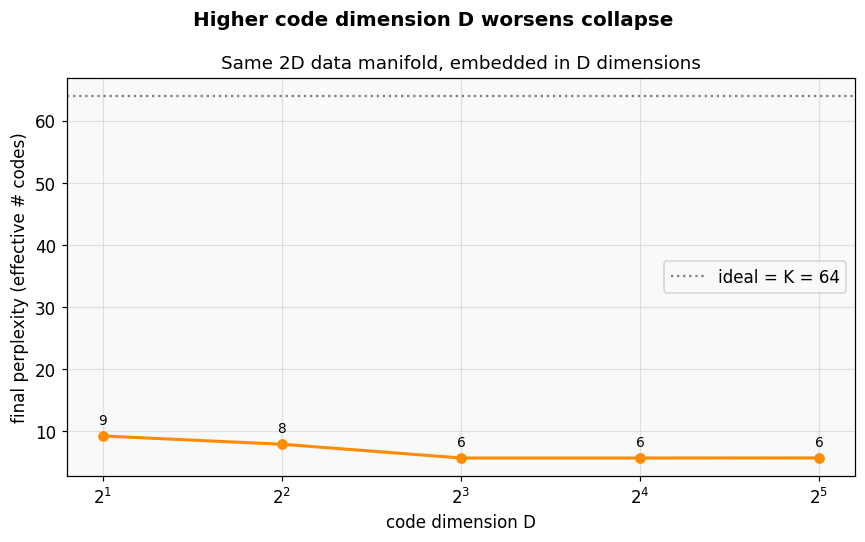

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Higher code dimension D worsens collapse', fontsize=13, fontweight='bold')

ax.plot(Ds, ppls, '-o', color='darkorange', lw=2)
ax.axhline(K, color='gray', ls=':', label=f'ideal = K = {K}')
ax.set_xlabel('code dimension D'); ax.set_ylabel('final perplexity (effective # codes)')
ax.set_xscale('log', base=2)
ax.set_title('Same 2D data manifold, embedded in D dimensions')
ax.legend()
for d, p in zip(Ds, ppls):
    ax.annotate(f'{p:.0f}', (d, p), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Final perplexity falls as D grows — at D=2 many codes stay alive, but by D=32 the effective vocabulary shrinks sharply, even though the underlying data is the same 2D manifold.
2. **Why it looks this way:** In high-dimensional space the data occupies a vanishingly thin slice, so randomly initialised codes are overwhelmingly likely to land far from it and never get chosen. Lower D packs codes near the data and keeps more of them in play.
3. **Key takeaway:** This is why modern VQ uses *low* code dimension with a *large* codebook — and often L2-normalises codes — to maximise utilization instead of inflating D.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Collapse in action | Bad init strands most codes; usage concentrates on a few, so K is an illusion. |
| 2. Perplexity detector | exp(usage entropy) cleanly separates healthy from collapsed runs and flags it early. |
| 3. Random restart | Reseeding dead codes to live data points restores utilization — a symptom fix. |
| 4. Dimensionality | High D leaves codes stranded off the thin data manifold; low D + large K maximises usage. |

### Connection to the broader theory

Collapse is the failure that [commitment loss](../research/02-commitment-loss.md) and [EMA updates](../research/03-ema-codebook-update.md) cannot reach, because both only touch chosen codes. The fixes here — restart, low D, L2 norm — patch a single learned codebook. The next two topics rework the quantizer itself: **Residual VQ** stacks codebooks for precision, and **FSQ** drops the learned codebook entirely, sidestepping collapse by construction.